# Hospital Readmission predictor

# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE


C:\Users\GREESHMA\Desktop\hospital_readmissions\myenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load Dataset

In [3]:
df = pd.read_csv("diabetic_data.csv")

df.shape
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [32]:
df.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,2,0,0,6,25,1,1,41,...,0,1,1,0,0,0,0,1,0,0
1,149190,55629189,2,0,10,1,1,7,3,59,...,0,3,1,0,0,0,0,0,1,0
2,64410,86047875,0,0,20,1,1,7,2,11,...,0,1,1,0,0,0,0,1,1,0
3,500364,82442376,2,1,30,1,1,7,2,44,...,0,3,1,0,0,0,0,0,1,0
4,16680,42519267,2,1,40,1,1,7,1,51,...,0,2,1,0,0,0,0,0,1,0


# Basic Understanding Visuals

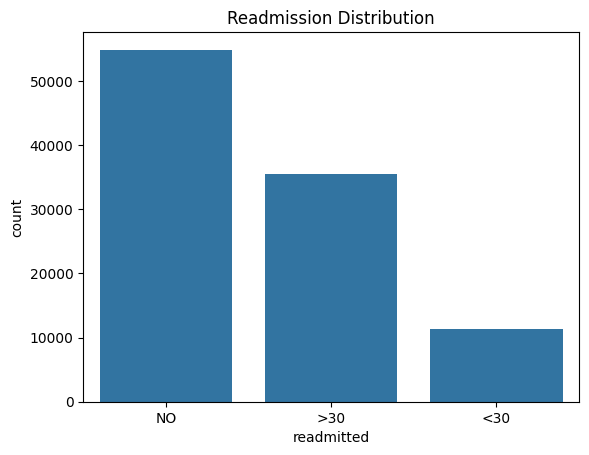

In [4]:
##Target distribution
sns.countplot(x='readmitted', data=df)
plt.title("Readmission Distribution")
plt.show()

# Handle Missing Values

In [5]:
df.replace('?', np.nan, inplace=True)

Missing Values Heatmap

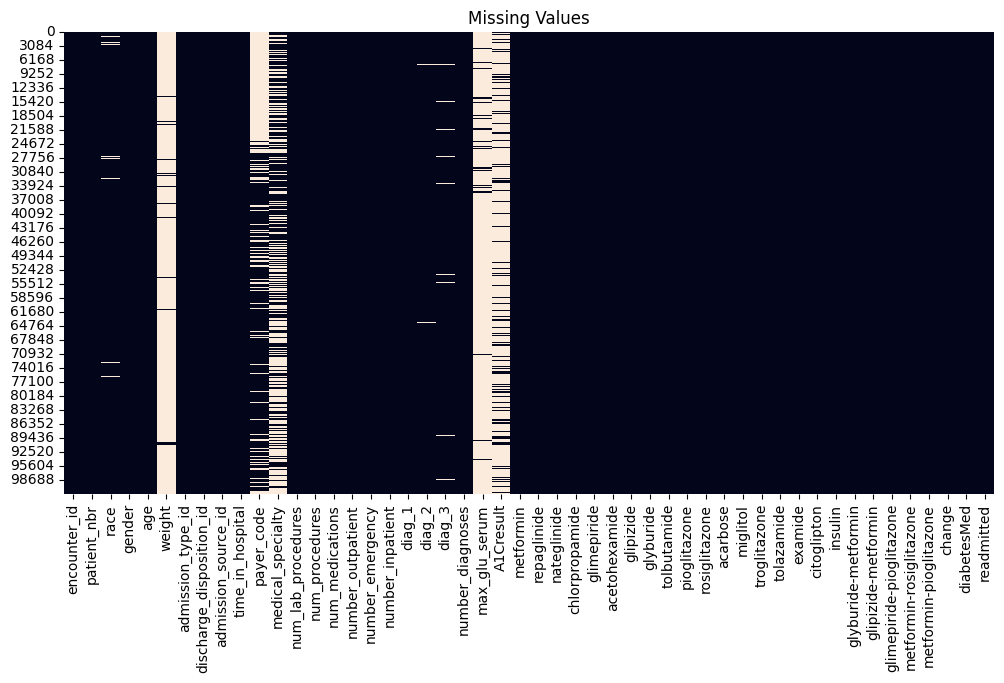

In [6]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()

Drop high-missing columns

In [7]:
df.drop(columns=['weight','payer_code','medical_specialty'], inplace=True)

# Remove Duplicates

In [8]:
df.drop_duplicates(inplace=True)

# Target Transformation

In [9]:
df['readmitted'] = df['readmitted'].map({
    '<30': 1,
    '>30': 0,
    'NO': 0
})

# Feature Engineering

In [10]:
df['age'] = df['age'].str.extract('(\d+)').astype(int)

# Exploratory Visualizations

Age vs Readmission


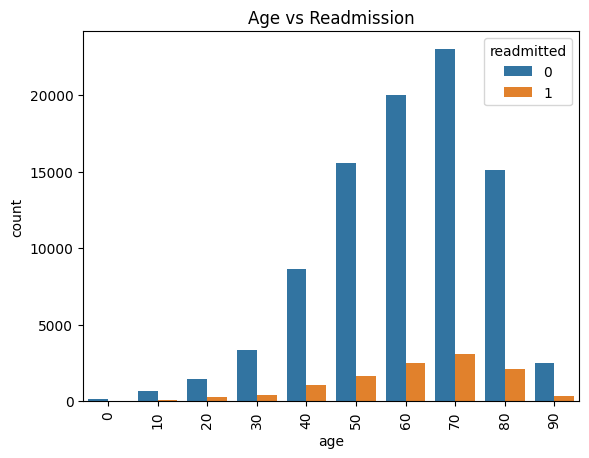

In [11]:
sns.countplot(x='age', hue='readmitted', data=df)
plt.xticks(rotation=90)
plt.title("Age vs Readmission")
plt.show()

Time in Hospital

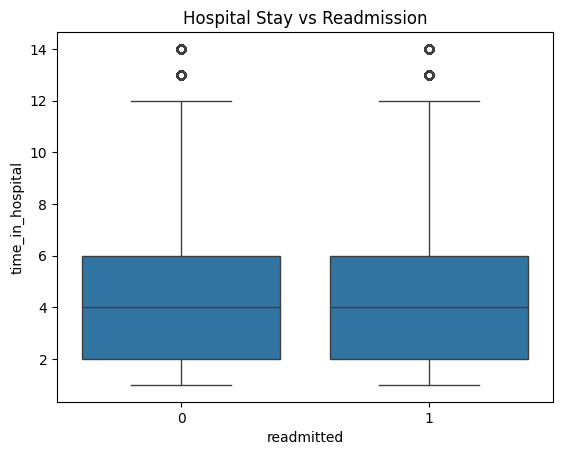

In [12]:
sns.boxplot(x='readmitted', y='time_in_hospital', data=df)
plt.title("Hospital Stay vs Readmission")
plt.show()

Lab Procedures

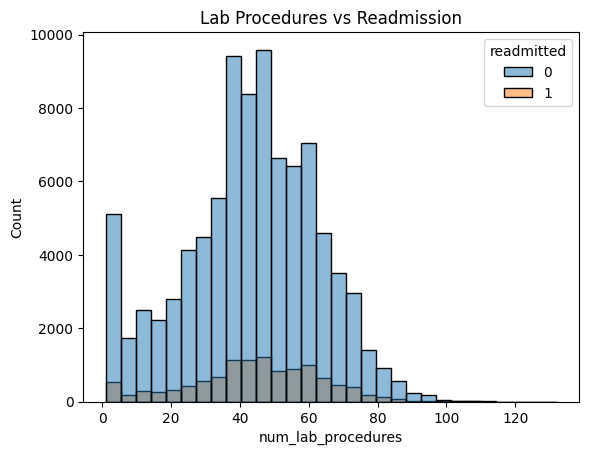

In [13]:
sns.histplot(data=df, x='num_lab_procedures', hue='readmitted', bins=30)
plt.title("Lab Procedures vs Readmission")
plt.show()

Number of Medications

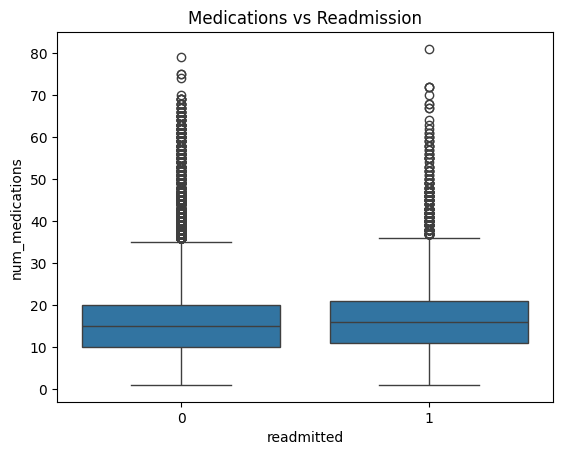

In [14]:
sns.boxplot(x='readmitted', y='num_medications', data=df)
plt.title("Medications vs Readmission")
plt.show()

# Encoding

In [15]:
cat_cols = df.select_dtypes(include='object').columns

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# Correlation Heatmap

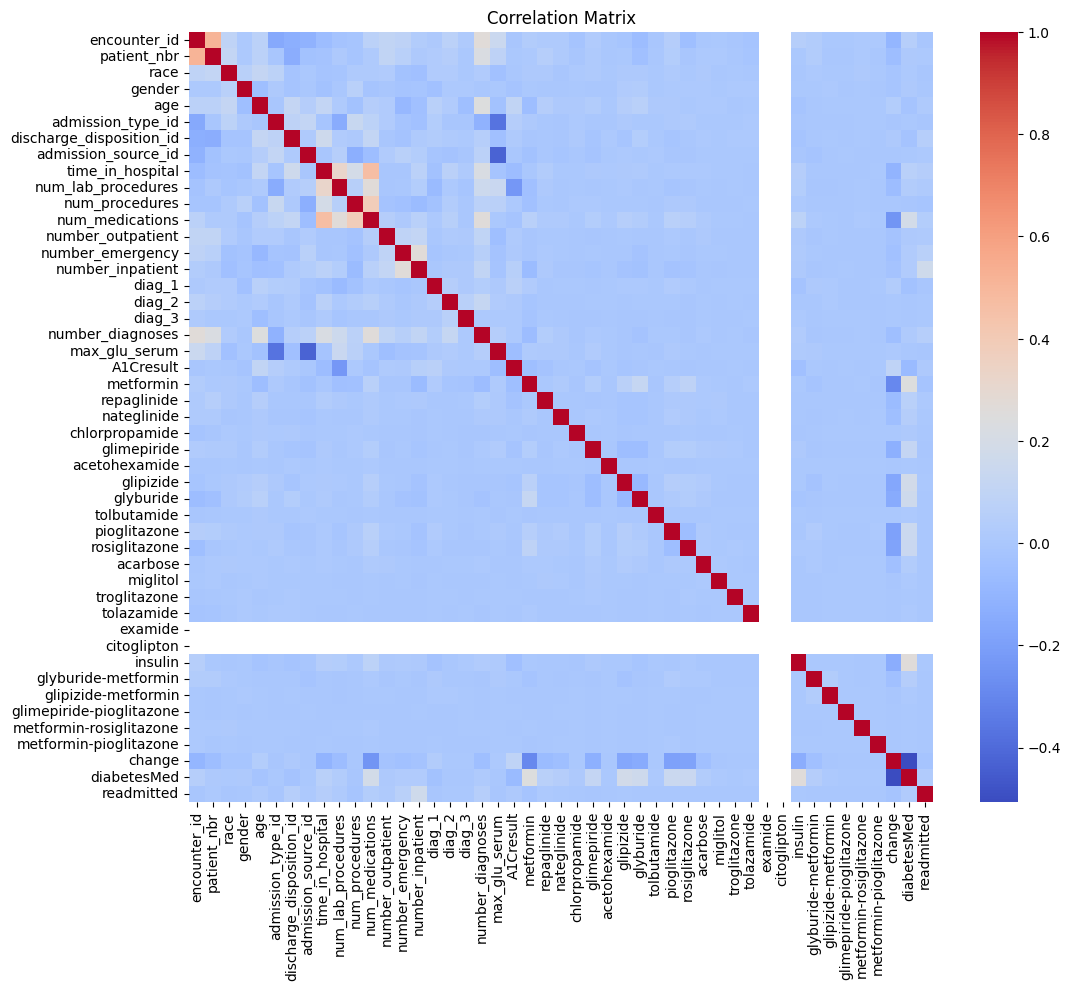

In [16]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# Split Data

In [17]:
X = df.drop('readmitted', axis=1)
y = df['readmitted']

# Handle Imbalance (SMOTE)

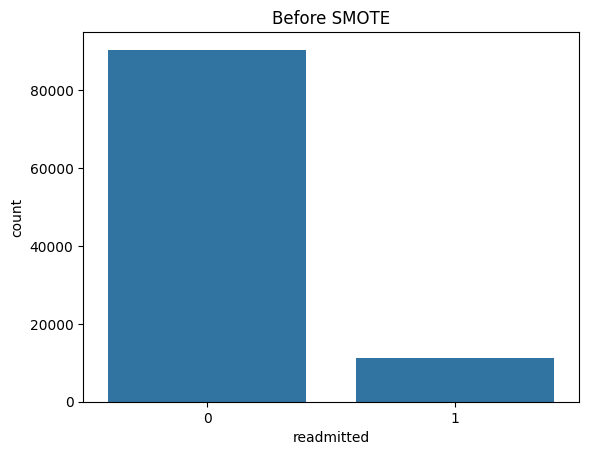

In [18]:
sns.countplot(x=y)
plt.title("Before SMOTE")
plt.show()


In [19]:
smote = SMOTE()
X_resampled, y_resampled = smote.fit_resample(X, y)

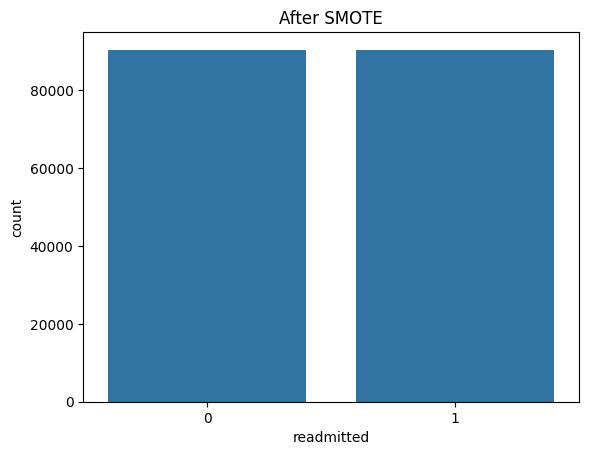

In [20]:
sns.countplot(x=y_resampled)
plt.title("After SMOTE")
plt.show()



# Train-Test Split



In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)

# Train Model


In [22]:
model = RandomForestClassifier(n_estimators=50, max_depth=10)
model.fit(X_train, y_train)


,n_estimators,50
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# Predictions

In [23]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

# Evaluation

Classification Report

In [24]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.89      0.85     17972
           1       0.88      0.80      0.84     18192

    accuracy                           0.84     36164
   macro avg       0.85      0.84      0.84     36164
weighted avg       0.85      0.84      0.84     36164



Confusion Matrix

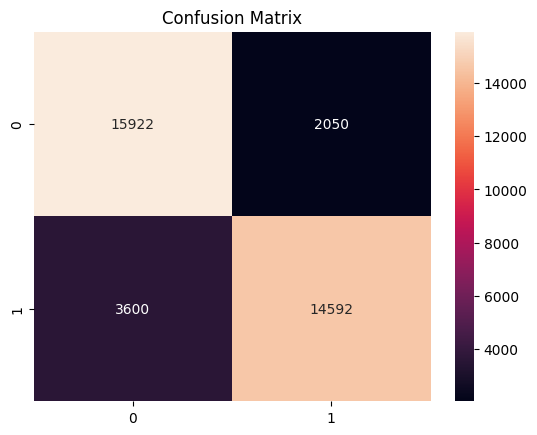

In [25]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

ROC Curve

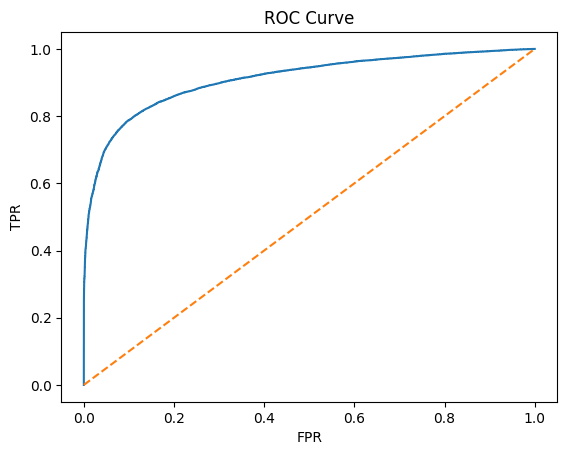

In [26]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

# Feature Importance

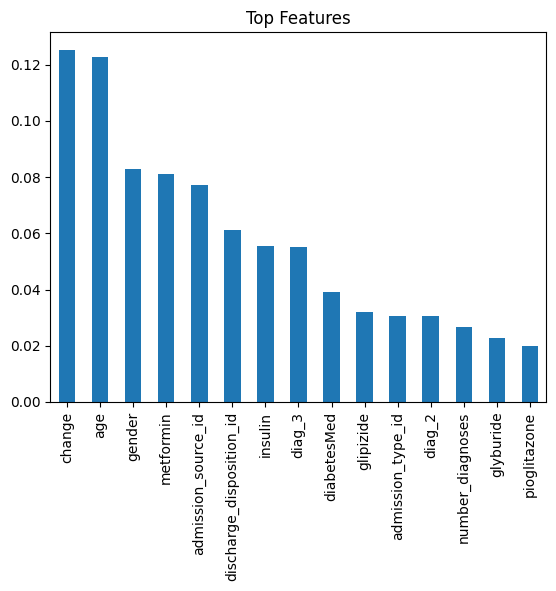

In [27]:
importances = model.feature_importances_
features = X.columns

feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

feat_imp.head(15).plot(kind='bar')
plt.title("Top Features")
plt.show()

In [30]:
import joblib

# Save label encoders for each categorical column
encoders = {}
cat_cols = ['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty',
            'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult',
            'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
            'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
            'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
            'miglitol', 'troglitazone', 'tolazamide', 'examide',
            'citoglipton', 'insulin', 'glyburide-metformin',
            'glipizide-metformin', 'glimepiride-pioglitazone',
            'metformin-rosiglitazone', 'metformin-pioglitazone',
            'change', 'diabetesMed']

for col in cat_cols:
    if col in df.columns:
        encoders[col] = dict(zip(df[col].dropna().unique(),
                                  range(len(df[col].dropna().unique()))))

joblib.dump(encoders, "encoders.pkl")
joblib.dump(list(X.columns), "model_features.pkl")
joblib.dump(model, "readmission_model.pkl")
print("Saved model, features, and encoders!")

Saved model, features, and encoders!
